# Insurance Fraud Detection: A Data Science Approach

A machine learning project comparing **Random Forest** and **Logistic Regression** for detecting fraudulent insurance claims.

**Stack:** Python · scikit-learn · pandas · matplotlib  
**Dataset:** Multi-source insurance claims data (demographics, policy, vehicle, claim records)

## Dataset Overview

> **Note:** The raw data files are not included in this repository. The snapshots below show the structure and representative sample rows for each of the five source tables, so readers can understand what information is available without accessing the private dataset.

| File | Rows | Columns | Description |
|---|---|---|---|
| `Traindata_with_Target.csv` | 28,836 | 2 | Customer IDs and fraud labels |
| `Train_Demographics.csv` | 28,836 | 10 | Insured person attributes |
| `Train_Policy.csv` | 28,836 | 10 | Policy details |
| `Train_Vehicle.csv` | 115,344 | 3 | Vehicle info in long (EAV) format |
| `Train_Claim.csv` | 28,836 | 19 | Incident and claim details |


In [ ]:
import pandas as pd
from IPython.display import display, HTML

def show(title, df):
    display(HTML(f"<h4 style='margin-top:1.2em'>{title}</h4>"))
    display(df)

# ── 1. Target ──────────────────────────────────────────────────
target_sample = pd.DataFrame({
    'CustomerID':    ['Cust20065', 'Cust37589', 'Cust24312', 'Cust5493', 'Cust7704'],
    'ReportedFraud': ['N', 'N', 'N', 'Y', 'Y']
})
show("1 · Traindata_with_Target.csv  (28,836 rows × 2 cols)", target_sample)

# ── 2. Demographics ────────────────────────────────────────────
demographics_sample = pd.DataFrame({
    'CustomerID':            ['Cust20065', 'Cust37589', 'Cust24312', 'Cust5493', 'Cust7704'],
    'InsuredAge':            [58, 34, 52, 25, 27],
    'InsuredZipCode':        [471784, 431937, 479320, 607763, 441783],
    'InsuredGender':         ['MALE', 'FEMALE', 'FEMALE', 'FEMALE', 'MALE'],
    'InsuredEducationLevel': ['JD', 'High School', 'PhD', 'College', 'Masters'],
    'InsuredOccupation':     ['sales', 'transport-moving', 'machine-op-inspct', 'exec-managerial', 'sales'],
    'InsuredHobbies':        ['video-games', 'polo', 'exercise', 'exercise', 'chess'],
    'CapitalGains':          [0, 51300, 0, 47400, 0],
    'CapitalLoss':           [-42700, 0, 0, -56100, 0],
    'Country':               ['US', 'US', 'US', 'US', 'US']
})
show("2 · Train_Demographics.csv  (28,836 rows × 10 cols)", demographics_sample)

# ── 3. Policy ──────────────────────────────────────────────────
policy_sample = pd.DataFrame({
    'CustomerID':               ['Cust20065', 'Cust37589', 'Cust24312', 'Cust5493', 'Cust7704'],
    'InsurancePolicyNumber':    ['POL-748321', 'POL-291044', 'POL-583910', 'POL-102847', 'POL-674529'],
    'CustomerLoyaltyPeriod':    [5, 2, 8, 1, 3],
    'DateOfPolicyCoverage':     ['2015-03-01', '2018-07-15', '2012-11-20', '2019-01-05', '2017-06-30'],
    'InsurancePolicyState':     ['OH', 'IL', 'IN', 'PA', 'OH'],
    'Policy_CombinedSingleLimit': ['100/300', '250/500', '100/300', '500/1000', '250/500'],
    'Policy_Deductible':        [500, 1000, 500, 2000, 1000],
    'PolicyAnnualPremium':      [1195.43, 1382.91, 987.60, 1748.22, 1103.75],
    'UmbrellaLimit':            [0, 2000000, 0, 5000000, 1000000],
    'InsuredRelationship':      ['spouse', 'own-child', 'not-in-family', 'unmarried', 'other-relative']
})
show("3 · Train_Policy.csv  (28,836 rows × 10 cols)", policy_sample)

# ── 4. Vehicle (long / EAV format) ────────────────────────────
vehicle_sample = pd.DataFrame({
    'CustomerID':              ['Cust20179', 'Cust21384', 'Cust33335', 'Cust27118', 'Cust21334'],
    'VehicleAttribute':        ['VehicleID', 'VehicleModel', 'VehicleMake', 'VehicleModel', 'VehicleYOM'],
    'VehicleAttributeDetails': ['Vehicle8898', 'Malibu', 'Toyota', 'Neon', '1996']
})
show("4 · Train_Vehicle.csv  (115,344 rows × 3 cols — long/EAV format, ~4 rows per customer)", vehicle_sample)

# ── 5. Claim ───────────────────────────────────────────────────
claim_sample = pd.DataFrame({
    'CustomerID':           ['Cust20065', 'Cust37589', 'Cust24312', 'Cust5493', 'Cust7704'],
    'DateOfIncident':       ['2015-01-06', '2015-01-17', '2015-02-05', '2015-01-06', '2015-02-13'],
    'TypeOfIncident':       ['Single Vehicle Collision', 'Vehicle Theft', 'Multi-vehicle Collision',
                             'Multi-vehicle Collision', 'Single Vehicle Collision'],
    'TypeOfCollission':     ['Rear Collision', '?', 'Side Collision', 'Front Collision', 'Rear Collision'],
    'SeverityOfIncident':   ['Major Damage', 'Minor Damage', 'Major Damage', 'Total Loss', 'Minor Damage'],
    'AuthoritiesContacted': ['Police', 'None', 'Ambulance', '?', 'Fire'],
    'IncidentState':        ['OH', 'IL', 'IN', 'PA', 'OH'],
    'IncidentCity':         ['Columbus', 'Springfield', 'Indianapolis', 'Pittsburgh', 'Akron'],
    'IncidentAddress':      ['123 Maple St', '456 Oak Ave', '789 Elm Rd', '321 Pine Blvd', '654 Cedar Ln'],
    'IncidentTime':         [19, 14, 21, 12, 3],
    'NumberOfVehicles':     [3, 1, 3, 3, 3],
    'PropertyDamage':       ['?', '?', '?', 'YES', 'NO'],
    'BodilyInjuries':       [1, 1, 0, 2, 1],
    'Witnesses':            [1, 1, 0, 0, 2],
    'PoliceReport':         ['?', 'YES', '?', '?', 'NO'],
    'AmountOfTotalClaim':   [43973, 62310, 42824, 45672, 81472],
    'AmountOfInjuryClaim':  [9396, 6539, 6069, 253, 7407],
    'AmountOfPropertyClaim':[4698, 6539, 6069, 5741, 14813],
    'AmountOfVehicleDamage':[29879, 49232, 30686, 39678, 59252]
})
show("5 · Train_Claim.csv  (28,836 rows × 19 cols)", claim_sample)


## 1. Project Overview

### Project Aim
The primary aim of this project is to develop and compare two machine learning models (Random Forest and Logistic Regression) to predict fraudulent insurance claims. The goal is to create a reliable fraud detection system that can help insurance companies identify potentially fraudulent claims while minimizing false positives which could harm customer relationships

### Project Objectives
1. **Data Analysis and Preprocessing**: Thoroughly analyze the insurance dataset, handle missing values using appropriate strategies, encode categorical variables, and prepare the data for machine learning while preventing data leakage.

2. **Model Development**: Build and optimize two predictive models:-
   - Random Forest classifier for robust ensemble-based predictions
   - Logistic Regression for interpretable probabilistic predictions

3. **Model Evaluation and Comparison**: Evaluate both models using appropriate metrics (accuracy, precision, recall, F1- score, ROC-AUC) and compare their performance to recommmend the best approach for fraud detection


## 2. Case Study Analysis

### Case study analysis

Insurance fraud detection presents unique challenges that require careful consideration of both technical and business factors:

1. **High Cost of False Positives**: Incorrectly flagging legitimate claims as fraudulent can damage customer trust and lead to customer churn. Insurance companies must maintain strong relationships with honest customers while identifying fraudulent ones.

2. **Significant Impact of False Negatives**: Missing actual fraudulent claims results in direct financial losses to the company. Undetected fraud also encourages more fraudulent behavior, creating longterm risks.

3. **Class Imbalance Challenge**: Fraudulent claims typically represent a small percentage of total claims, creating an imbalanced dataset. However, we will address this through careful model evaluation and class weighting rather than synthetic data generation

4. **Regulatory and Interpretability Requirements**: Insurance is a heavily regulated industry where decisions must be explainable. Models need to provide clear reasoning for fraud predictions to satisfy regulatory requirements and internal audits

5. **Data Leakage Prevention**: Its crucial to only use information that would be available at the time of initial claim filing, not information determined after fraud investigation is complete.

**Strategy**: To address these challenges, we will implement a careful feature selection process to prevent data leakage, handle missing values by marking them as "unknown" to preserve information, and evaluate models using both technical metrics (precision, recall, F1score) and business-relevant measures

## 3. Pre-processing applied

This section implements comprehensive data preprocessing to prepare the insurance fraud dataset for machine learning. Each preprocessing step is designed to handle specific data quality issues while preventing data leakage.

### Import Required Libraries

In [1]:
# Import essential libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, balanced_accuracy_score
import warnings
warnings.filterwarnings('ignore')

### Data Loading and Initial Exploration

In [2]:
# Load all datasets
target_df = pd.read_csv('./TrainData/Traindata_with_Target.csv')
demographics_df = pd.read_csv('./TrainData/Train_Demographics.csv')
policy_df = pd.read_csv('./TrainData/Train_Policy.csv')
vehicle_df = pd.read_csv('./TrainData/Train_Vehicle.csv')
claim_df = pd.read_csv('./TrainData/Train_Claim.csv')

print("Dataset shapes:")
print(f"Target: {target_df.shape}")
print(f"Demographics: {demographics_df.shape}")
print(f"Policy: {policy_df.shape}")
print(f"Vehicle: {vehicle_df.shape}")
print(f"Claim: {claim_df.shape}")

print("\nSample of vehicle data:")
print(vehicle_df.head(10))

Dataset shapes:
Target: (28836, 2)
Demographics: (28836, 10)
Policy: (28836, 10)
Vehicle: (115344, 3)
Claim: (28836, 19)

Sample of vehicle data:
  CustomerID VehicleAttribute VehicleAttributeDetails
0  Cust20179        VehicleID             Vehicle8898
1  Cust21384     VehicleModel                  Malibu
2  Cust33335      VehicleMake                  Toyota
3  Cust27118     VehicleModel                    Neon
4  Cust13038        VehicleID            Vehicle30212
5   Cust1801        VehicleID            Vehicle24096
6  Cust30237     VehicleModel                     RAM
7  Cust21334       VehicleYOM                    1996
8  Cust26634       VehicleYOM                    1999
9  Cust20624      VehicleMake               Chevrolet


### Vehicle Data Preprocessing

In [ ]:
# Extract numerical part from VehicleID
def extract_vehicle_id_number(vehicle_id):
    if pd.isna(vehicle_id) or vehicle_id == 'unknown':
        return np.nan
    # Extract numbers from strings
    numbers = re.findall(r'\d+', str(vehicle_id))
    if numbers:
        return int(numbers[0])  # take first number found
    return np.nan

# Preprocess VehicleID to extract numerical values
vehicle_df_processed = vehicle_df.copy()
vehicle_id_mask = vehicle_df_processed['VehicleAttribute'] == 'VehicleID'
vehicle_df_processed.loc[vehicle_id_mask, 'VehicleAttributeDetails'] = vehicle_df_processed.loc[vehicle_id_mask, 'VehicleAttributeDetails'].apply(extract_vehicle_id_number)

print("Sample of processed vehicle data:")
print(vehicle_df_processed[vehicle_df_processed['VehicleAttribute'] == 'VehicleID'].head())

# Pivot vehicle data to get one row per customer
vehicle_pivot = vehicle_df_processed.pivot_table(
    index='CustomerID', 
    columns='VehicleAttribute', 
    values='VehicleAttributeDetails', 
    aggfunc='first'
).reset_index()

# Flatten column names
vehicle_pivot.columns.name = None
vehicle_pivot.columns = ['CustomerID'] + [f'Vehicle_{col}' for col in vehicle_pivot.columns[1:]]

print(f"\nVehicle pivot shape: {vehicle_pivot.shape}")
print("Vehicle columns:", vehicle_pivot.columns.tolist())

Sample of processed vehicle data:
   CustomerID VehicleAttribute VehicleAttributeDetails
0   Cust20179        VehicleID                    8898
4   Cust13038        VehicleID                   30212
5    Cust1801        VehicleID                   24096
10  Cust14947        VehicleID                   15216
16  Cust19144        VehicleID                   29018

Vehicle pivot shape: (28836, 5)
Vehicle columns: ['CustomerID', 'Vehicle_VehicleID', 'Vehicle_VehicleMake', 'Vehicle_VehicleModel', 'Vehicle_VehicleYOM']


### Merging and Data Integration

In [ ]:
# Merge datasets
df = target_df.merge(demographics_df, on='CustomerID', how='left')
df = df.merge(policy_df, on='CustomerID', how='left')
df = df.merge(vehicle_pivot, on='CustomerID', how='left')
df = df.merge(claim_df, on='CustomerID', how='left')

print(f"Final merged dataset shape: {df.shape}")
print(f"\nColumns in merged dataset:")
print(df.columns.tolist())
print(f"\nTarget variable distribution:")
print(df['ReportedFraud'].value_counts())
df

Final merged dataset shape: (28836, 42)

Columns in merged dataset:
['CustomerID', 'ReportedFraud', 'InsuredAge', 'InsuredZipCode', 'InsuredGender', 'InsuredEducationLevel', 'InsuredOccupation', 'InsuredHobbies', 'CapitalGains', 'CapitalLoss', 'Country', 'InsurancePolicyNumber', 'CustomerLoyaltyPeriod', 'DateOfPolicyCoverage', 'InsurancePolicyState', 'Policy_CombinedSingleLimit', 'Policy_Deductible', 'PolicyAnnualPremium', 'UmbrellaLimit', 'InsuredRelationship', 'Vehicle_VehicleID', 'Vehicle_VehicleMake', 'Vehicle_VehicleModel', 'Vehicle_VehicleYOM', 'DateOfIncident', 'TypeOfIncident', 'TypeOfCollission', 'SeverityOfIncident', 'AuthoritiesContacted', 'IncidentState', 'IncidentCity', 'IncidentAddress', 'IncidentTime', 'NumberOfVehicles', 'PropertyDamage', 'BodilyInjuries', 'Witnesses', 'PoliceReport', 'AmountOfTotalClaim', 'AmountOfInjuryClaim', 'AmountOfPropertyClaim', 'AmountOfVehicleDamage']

Target variable distribution:
ReportedFraud
N    21051
Y     7785
Name: count, dtype: int64


,CustomerID,ReportedFraud,InsuredAge,InsuredZipCode,InsuredGender,InsuredEducationLevel,InsuredOccupation,InsuredHobbies,CapitalGains,CapitalLoss,...,IncidentTime,NumberOfVehicles,PropertyDamage,BodilyInjuries,Witnesses,PoliceReport,AmountOfTotalClaim,AmountOfInjuryClaim,AmountOfPropertyClaim,AmountOfVehicleDamage
0,Cust20065,N,58,471784,MALE,JD,sales,video-games,0,-42700,...,19,3,?,1,1,?,43973,9396,4698,29879
1,Cust37589,N,34,431937,FEMALE,High School,transport-moving,polo,51300,0,...,14,1,?,1,1,YES,62310,6539,6539,49232
2,Cust24312,N,52,479320,FEMALE,PhD,machine-op-inspct,exercise,0,0,...,21,3,?,0,0,?,42824,6069,6069,30686
3,Cust5493,Y,25,607763,FEMALE,College,exec-managerial,exercise,47400,-56100,...,12,3,YES,2,0,?,45672,253,5741,39678
4,Cust7704,Y,27,441783,MALE,Masters,sales,chess,0,0,...,3,3,NO,1,2,NO,81472,7407,14813,59252
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28831,Cust9773,N,39,454139,MALE,JD,farming-fishing,basketball,0,0,...,16,1,NO,1,2,?,50515,5543,5543,39429
28832,Cust38439,N,21,463809,MALE,Associate,prof-specialty,golf,20000,-75000,...,19,3,YES,2,0,?,94920,8678,8738,77504
28833,Cust38444,N,35,444155,MALE,Associate,prof-specialty,golf,0,-75000,...,16,3,YES,2,0,NO,87893,13224,7990,66679
28834,Cust26466,N,40,603123,FEMALE,Masters,exec-managerial,reading,0,-63900,...,12,1,?,1,1,?,7284,728,1457,5099


### Preparing Labels

Target variable after encoding:
ReportedFraud
0    21051
1     7785
Name: count, dtype: int64
Fraud rate: 0.270


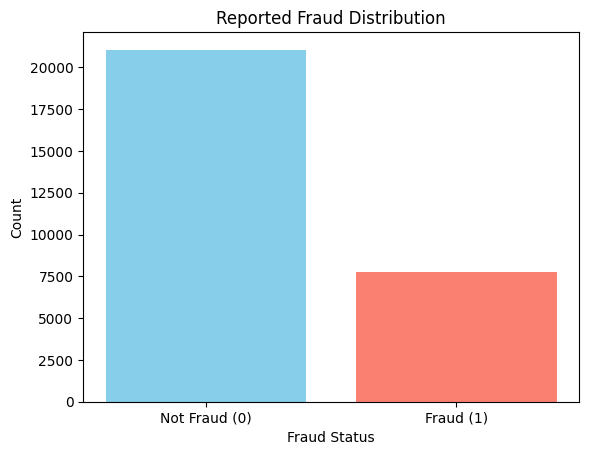

In [5]:
# Convert target variable to binary
df['ReportedFraud'] = df['ReportedFraud'].map({'Y': 1, 'N': 0})

print("Target variable after encoding:")
print(df['ReportedFraud'].value_counts())
print(f"Fraud rate: {df['ReportedFraud'].mean():.3f}")

# Count of each class
counts = df['ReportedFraud'].value_counts().sort_index()

# Bar chart
plt.bar(['Not Fraud (0)', 'Fraud (1)'], counts, color=['skyblue', 'salmon'])
plt.title('Reported Fraud Distribution')
plt.xlabel('Fraud Status')
plt.ylabel('Count')
plt.show()

### Feature Selection to Prevent Data Leakage

In [ ]:
# Define features that should be available at time of claim filing (no data leakage)
# exclude features that are determined AFTER fraud investigation

# Demographics features (available at policy creation)
demographics_features = ['InsuredAge', 'InsuredZipCode', 'InsuredGender', 'InsuredEducationLevel', 
                        'InsuredOccupation', 'InsuredHobbies', 'CapitalGains', 'CapitalLoss', 'Country']

# Policy features (available at policy creation)
policy_features = ['CustomerLoyaltyPeriod', 'InsurancePolicyState', 'Policy_CombinedSingleLimit', 
                  'Policy_Deductible', 'PolicyAnnualPremium', 'UmbrellaLimit', 'InsuredRelationship']

# Vehicle featuress (available at policy creation)
vehicle_features = ['Vehicle_VehicleID', 'Vehicle_VehicleMake', 'Vehicle_VehicleModel', 'Vehicle_VehicleYOM']

# Claims features that would be available at initial filing (NOT final amounts)
# Exclude: AmountOfTotalClaim, AmountOfInjuryClaim, AmountOfPropertyClaim, AmountOfVehicleDamage
# These are determined AFTER investigation and would cause data leakage
claim_features = ['TypeOfIncident', 'TypeOfCollission', 'SeverityOfIncident', 'AuthoritiesContacted',
                 'IncidentState', 'IncidentCity', 'IncidentTime', 'NumberOfVehicles', 
                 'PropertyDamage', 'BodilyInjuries', 'Witnesses', 'PoliceReport']

# Combine valid features
valid_features = demographics_features + policy_features + vehicle_features + claim_features

# Filter to only include features that exist in the dataset
available_features = [f for f in valid_features if f in df.columns]

print(f"Total valid features selected: {len(available_features)}")
print("\nSelected features:")
for i, feature in enumerate(available_features):
    print(f"{i+1:2d}. {feature}")

print("\nExcluded features (potential data leakage):")
excluded_features = ['AmountOfTotalClaim', 'AmountOfInjuryClaim', 'AmountOfPropertyClaim', 
                    'AmountOfVehicleDamage', 'DateOfPolicyCoverage', 'DateOfIncident', 
                    'InsurancePolicyNumber', 'IncidentAddress']
for feature in excluded_features:
    if feature in df.columns:
        print(f"- {feature}")

Total valid features selected: 32

Selected features:
 1. InsuredAge
 2. InsuredZipCode
 3. InsuredGender
 4. InsuredEducationLevel
 5. InsuredOccupation
 6. InsuredHobbies
 7. CapitalGains
 8. CapitalLoss
 9. Country
10. CustomerLoyaltyPeriod
11. InsurancePolicyState
12. Policy_CombinedSingleLimit
13. Policy_Deductible
14. PolicyAnnualPremium
15. UmbrellaLimit
16. InsuredRelationship
17. Vehicle_VehicleID
18. Vehicle_VehicleMake
19. Vehicle_VehicleModel
20. Vehicle_VehicleYOM
21. TypeOfIncident
22. TypeOfCollission
23. SeverityOfIncident
24. AuthoritiesContacted
25. IncidentState
26. IncidentCity
27. IncidentTime
28. NumberOfVehicles
29. PropertyDamage
30. BodilyInjuries
31. Witnesses
32. PoliceReport

Excluded features (potential data leakage):
- AmountOfTotalClaim
- AmountOfInjuryClaim
- AmountOfPropertyClaim
- AmountOfVehicleDamage
- DateOfPolicyCoverage
- DateOfIncident
- InsurancePolicyNumber
- IncidentAddress


### Handling Missing Values with 'Unknown' Strategy

In [7]:
# Create feature matrix with only valid features
X = df[available_features].copy()
y = df['ReportedFraud']

# Check missing values
missing_values = X.isnull().sum()
missing_percent = (missing_values / len(X)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing_values,
    'Missing_Percent': missing_percent
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Percent', ascending=False)

print("Missing values summary:")
print(missing_df.head(10))

# Replace '?' with NaN for proper handling
X = X.replace('?', np.nan)

# Handle missing values by replacing with 'unknown' for categorical and median for numerical
for column in X.columns:
    if X[column].dtype == 'object':
        # For categorical columns, fill with 'unknown'
        X[column] = X[column].fillna('unknown')
    else:
        # For numerical columns, fill with median
        X[column] = X[column].fillna(X[column].median())

print(f"\nMissing values after handling: {X.isnull().sum().sum()}")
print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

Missing values summary:
                      Missing_Count  Missing_Percent
AuthoritiesContacted           2692         9.335553
InsuredGender                    30         0.104037
Country                           2         0.006936

Missing values after handling: 0
Feature matrix shape: (28836, 32)
Target vector shape: (28836,)


### Handling Duplicate Values

In [ ]:
# Check for duplicates in the feature matrx
combined_data = pd.concat([X, y], axis=1)
duplicates = combined_data.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

if duplicates > 0:
    combined_data = combined_data.drop_duplicates()
    X = combined_data.drop('ReportedFraud', axis=1)
    y = combined_data['ReportedFraud']
    print(f"Removed {duplicates} duplicate rows")
    print(f"Dataset shape after removing duplicates: {X.shape}")

Number of duplicate rows: 0


### Data Type Conversion and Feature Engineering

In [ ]:
# Convert Vehicle_VehicleID to numeric (already preprocessed
if 'Vehicle_VehicleID' in X.columns:
    X['Vehicle_VehicleID'] = pd.to_numeric(X['Vehicle_VehicleID'], errors='coerce')
    X['Vehicle_VehicleID'] = X['Vehicle_VehicleID'].fillna(X['Vehicle_VehicleID'].median())

# Convert Vehicle_VehicleYOM to numeric
if 'Vehicle_VehicleYOM' in X.columns:
    X['Vehicle_VehicleYOM'] = pd.to_numeric(X['Vehicle_VehicleYOM'], errors='coerce')
    X['Vehicle_VehicleYOM'] = X['Vehicle_VehicleYOM'].fillna(X['Vehicle_VehicleYOM'].median())

# Convert other numeric column
numeric_columns = ['InsuredAge', 'InsuredZipCode', 'CapitalGains', 'CapitalLoss', 
                  'CustomerLoyaltyPeriod', 'Policy_Deductible', 'PolicyAnnualPremium', 
                  'UmbrellaLimit', 'IncidentTime', 'NumberOfVehicles', 'BodilyInjuries', 'Witnesses']

for col in numeric_columns:
    if col in X.columns:
        X[col] = pd.to_numeric(X[col], errors='coerce')
        X[col] = X[col].fillna(X[col].median())

print("Data type conversion completed")
print(f"Feature matrix shape: {X.shape}")

Data type conversion completed
Feature matrix shape: (28836, 32)


### Identifying Categorical and Numerical Features

In [ ]:
# Identify categorical and numerical column
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Categorical features ({len(categorical_features)}):")
for i, feature in enumerate(categorical_features):
    print(f"{i+1:2d}. {feature}")

print(f"\nNumerical features ({len(numerical_features)}):")
for i, feature in enumerate(numerical_features):
    print(f"{i+1:2d}. {feature}")

print(f"\nTotal features: {len(categorical_features) + len(numerical_features)}")

Categorical features (18):
 1. InsuredGender
 2. InsuredEducationLevel
 3. InsuredOccupation
 4. InsuredHobbies
 5. Country
 6. InsurancePolicyState
 7. Policy_CombinedSingleLimit
 8. InsuredRelationship
 9. Vehicle_VehicleMake
10. Vehicle_VehicleModel
11. TypeOfIncident
12. TypeOfCollission
13. SeverityOfIncident
14. AuthoritiesContacted
15. IncidentState
16. IncidentCity
17. PropertyDamage
18. PoliceReport

Numerical features (14):
 1. InsuredAge
 2. InsuredZipCode
 3. CapitalGains
 4. CapitalLoss
 5. CustomerLoyaltyPeriod
 6. Policy_Deductible
 7. PolicyAnnualPremium
 8. UmbrellaLimit
 9. Vehicle_VehicleID
10. Vehicle_VehicleYOM
11. IncidentTime
12. NumberOfVehicles
13. BodilyInjuries
14. Witnesses

Total features: 32


### Correlation Analysis and Feature Selection

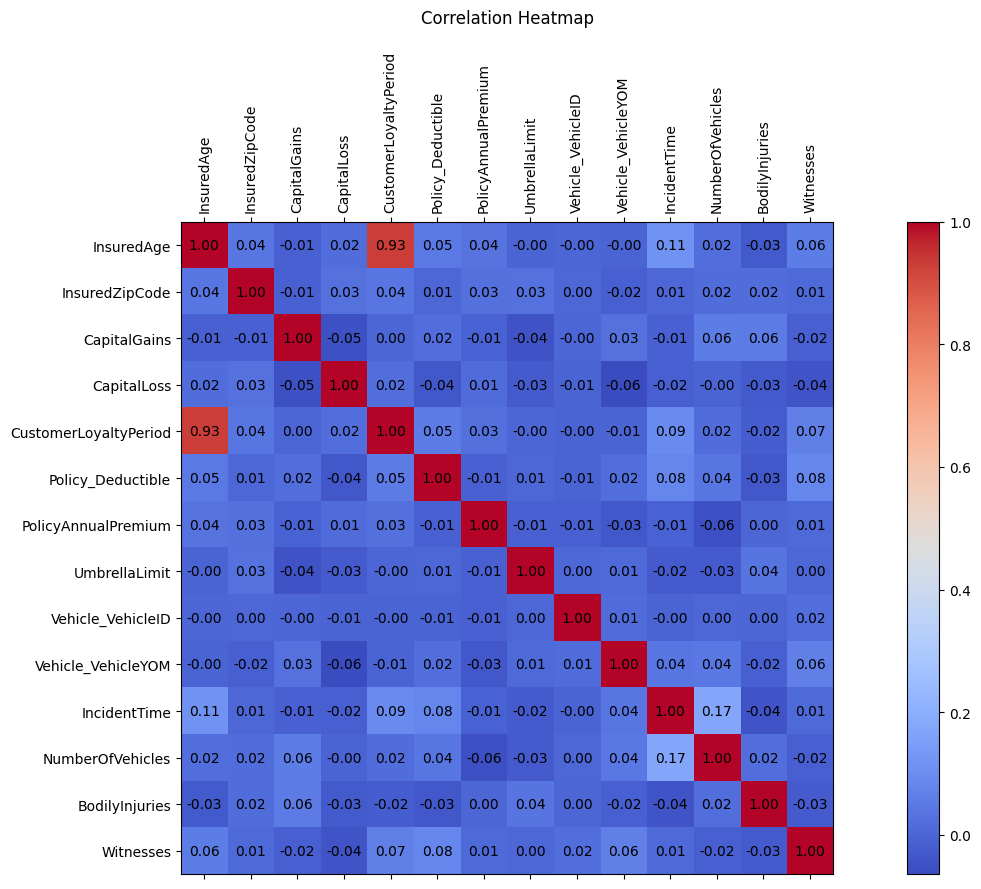

Found 1 highly correlated feature pairs (>0.9):
InsuredAge - CustomerLoyaltyPeriod: 0.933
Removed 1 highly correlated features


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Analyze correlation among numerical features
if len(numerical_features) > 1:
    # Compute correlation matrix
    correlation_matrix = X[numerical_features].corr()
    
    # Plot heatmap using matplotlib only
    corr_values = correlation_matrix.values
    labels = correlation_matrix.columns

    fig, ax = plt.subplots(figsize=(15, 9))
    cax = ax.matshow(corr_values, cmap='coolwarm')
    fig.colorbar(cax)

    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=90)
    ax.set_yticklabels(labels)

    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, f"{corr_values[i, j]:.2f}", va='center', ha='center', color='black')

    plt.title("Correlation Heatmap", pad=20)
    plt.tight_layout()
    plt.show()

    # find highly correlated features (>0.9)
    high_corr_pairs = []
    for i in range(len(labels)):
        for j in range(i + 1, len(labels)):
            corr_val = corr_values[i, j]
            if abs(corr_val) > 0.9:
                high_corr_pairs.append((labels[i], labels[j], corr_val))
    
    print(f"Found {len(high_corr_pairs)} highly correlated feature pairs (>0.9):")
    for f1, f2, val in high_corr_pairs:
        print(f"{f1} - {f2}: {val:.3f}")
    
    # Remove one feature from each highly correlated pair
    features_to_remove = []
    for _, f2, _ in high_corr_pairs:
        if f2 not in features_to_remove:
            features_to_remove.append(f2)
    
    if features_to_remove:
        X = X.drop(columns=features_to_remove)
        numerical_features = [f for f in numerical_features if f not in features_to_remove]
        print(f"Removed {len(features_to_remove)} highly correlated features")

### Variance Analysis

In [12]:
# Check variance of numerical features
if len(numerical_features) > 0:
    variance_analysis = X[numerical_features].var().sort_values()
    low_variance_features = variance_analysis[variance_analysis < 0.01].index.tolist()
    
    print(f"Features with low variance (<0.01): {len(low_variance_features)}")
    if low_variance_features:
        print(f"Low variance features: {low_variance_features}")
        X = X.drop(columns=low_variance_features)
        numerical_features = [f for f in numerical_features if f not in low_variance_features]
        print(f"Updated feature matrix shape: {X.shape}")

Features with low variance (<0.01): 0


### Data Splitting

In [13]:
# Stratified train-test split to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"\nTraining set class distribution:")
print(y_train.value_counts(normalize=True))
print(f"\nTest set class distribution:")
print(y_test.value_counts(normalize=True))

Training set shape: (23068, 31)
Test set shape: (5768, 31)

Training set class distribution:
ReportedFraud
0    0.730016
1    0.269984
Name: proportion, dtype: float64

Test set class distribution:
ReportedFraud
0    0.730062
1    0.269938
Name: proportion, dtype: float64


In [14]:
# Update categorical and numerical features after feature selection
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ]
)

## 4. Technique 1: Random Forest

### 4.1 Motivation for choosing Random Forest and schematic figure

Random Forest is an excellent choice for fraud detection due to several key advantages:

**1. Robustness to Outliers**: Insurance data often contains outliers (unusually high claims, rare incident types). Random Forest's ensemble approach makes it less sensitive to these outliers compared to single decision tree

**2. Handles Mixed Data Types**: Our dataset contains both categorical (gender, occupation, incident type) and numerical (claim amounts, age, premiums features. Random Forest naturally handles this mixed data without requiring extensive preprocessing .

**3. Built-in Feature Selection**: Random Forest provides feature importance scores, helping identify which factors are most predictive of fraud. This is valuable for business understanding and regulatory compliance

**4. Reduced Overfitting**: The ensemble of multiple trees with random feature selection reduces overfitting compared to single decision trees, leading to better generalization.

**5. Handles Class Imbalance**: Random Forest can naturally handle imbalanced datasets through it voting mechanism and can be further tuned with class weights if needed

---

### Analysis Process Schematic:
```
Raw Data → Feature Selection → Preprocessing Pipeline → Random Forest → Predictions
    ↓              ↓                    ↓                    ↓              ↓
Multiple CSVs → No Leakage → Scaling/Encoding → Ensemble Trees → Fraud/No Fraud
```

### 4.2 Setting Hyperparameters and Rationale

In [15]:
# Define Random Forest hyperparameter grid
rf_param_grid = {
    'classifier__n_estimators': [100, 200],  # Number of trees
    'classifier__max_depth': [10, 20, None],  # Tree depth
    'classifier__min_samples_split': [2, 5],  # Minimum samples to split
    'classifier__min_samples_leaf': [1, 2],   # Minimum samples in leaf
    'classifier__max_features': ['sqrt', 'log2'],  # Features per split
    'classifier__class_weight': ['balanced', None]  # Handle class imbalance
}

### 4.3 Model Pipeline and Hyperparameter Optimization

In [ ]:
# Create Random Forest pipeline
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Grid search with cross-validation
rf_grid_search = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    cv=3,  # 3 fold CV for faster computation
    scoring='f1',  # F1 score balances precision and recall
    n_jobs=-1,
    verbose=1
)

print("Training Random Forest with hyperparameter optimization...")
rf_grid_search.fit(X_train, y_train)

print(f"\nBest Random Forest parameters:")
for param, value in rf_grid_search.best_params_.items():
    print(f"{param}: {value}")
print(f"\nBest cross-validation F1 score: {rf_grid_search.best_score_:.4f}")

Training Random Forest with hyperparameter optimization...
Fitting 3 folds for each of 96 candidates, totalling 288 fits

Best Random Forest parameters:
classifier__class_weight: balanced
classifier__max_depth: None
classifier__max_features: log2
classifier__min_samples_leaf: 2
classifier__min_samples_split: 2
classifier__n_estimators: 200

Best cross-validation F1 score: 0.8451


### 4.4 Training Set Performance Metrics

Random Forest Training Set Performance:
Accuracy: 0.9743
Precision: 0.9620
Recall: 0.9422
F1 Score: 0.9520
Balanced Accuracy: 0.9642


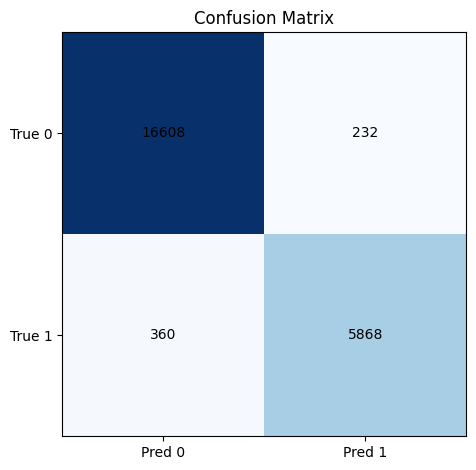

In [19]:
# Get the best Random Forest model
best_rf_model = rf_grid_search.best_estimator_

# Training set predictions
y_train_pred_rf = best_rf_model.predict(X_train)
y_train_proba_rf = best_rf_model.predict_proba(X_train)[:, 1]

# Calculate training metrics
train_accuracy_rf = accuracy_score(y_train, y_train_pred_rf)
train_precision_rf = precision_score(y_train, y_train_pred_rf)
train_recall_rf = recall_score(y_train, y_train_pred_rf)
train_f1_rf = f1_score(y_train, y_train_pred_rf)
train_balanced_acc_rf = balanced_accuracy_score(y_train, y_train_pred_rf)

print("Random Forest Training Set Performance:")
print(f"Accuracy: {train_accuracy_rf:.4f}")
print(f"Precision: {train_precision_rf:.4f}")
print(f"Recall: {train_recall_rf:.4f}")
print(f"F1 Score: {train_f1_rf:.4f}")
print(f"Balanced Accuracy: {train_balanced_acc_rf:.4f}")

# Confusion Matrix
cm_train_rf = confusion_matrix(y_train, y_train_pred_rf)
plt.imshow(cm_train_rf, cmap='Blues')
plt.title('Confusion Matrix')
plt.xticks([0, 1], ['Pred 0', 'Pred 1'])
plt.yticks([0, 1], ['True 0', 'True 1'])

# write counts
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_train_rf[i, j], ha='center', va='center', color='black')

plt.tight_layout()
plt.show()

### 4.5 Feature Importance Analysis

Top 10 Most Important Features:
                             feature  importance
127  SeverityOfIncident_Minor Damage    0.059883
128    SeverityOfIncident_Total Loss    0.049502
1                     InsuredZipCode    0.043001
5                PolicyAnnualPremium    0.035547
38              InsuredHobbies_chess    0.034028
0                         InsuredAge    0.032175
9                       IncidentTime    0.030917
4                  Policy_Deductible    0.028746
8                 Vehicle_VehicleYOM    0.028001
39          InsuredHobbies_cross-fit    0.027884


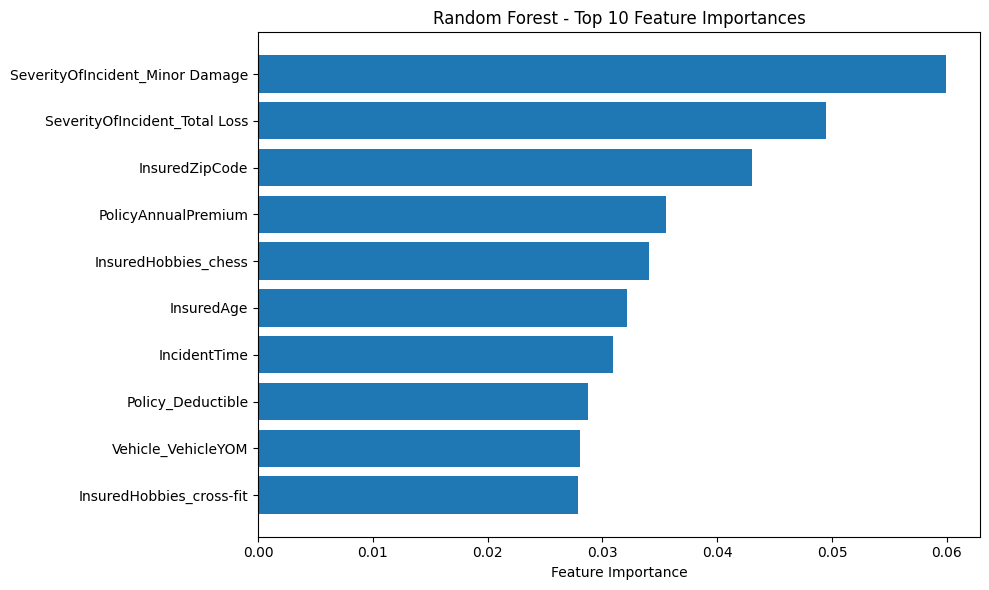

In [20]:
# Get feature names after preprocessing
feature_names = (numerical_features + 
                list(best_rf_model.named_steps['preprocessor']
                    .named_transformers_['cat']
                    .get_feature_names_out(categorical_features)))

# Get feature importances
feature_importance = best_rf_model.named_steps['classifier'].feature_importances_
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("Top 10 Most Important Features:")
print(importance_df.head(10))

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(range(10), importance_df.head(10)['importance'])
plt.yticks(range(10), importance_df.head(10)['feature'])
plt.xlabel('Feature Importance')
plt.title('Random Forest - Top 10 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 5. Technique 2: Logistic Regression

### 5.1 Motivation for choosing Logistic Regression and schematic figure

Logistic Regression is a fundamental choice for fraud detection with several compelling advantages:

**1. High Interpretability**: Logistic regression provides clear interpretable coefficients that show how each feature influences fraud probability.. This is crucial for regulatory compliance and business understanding in insurance.

**2. Probabilistic Output**: Unlike tree-based methods, logistic regression naturally outputs probabilities, allowing for flexible threshold setting based on business costs of false positives vs false negatives.

**3. Computational Efficiency**: Logistic regression is fast to train and predict, making it suitable for realtime fraud detection systems where quick decisions are needed.

**4. Baseline Performance**: As a linear model it provides an exccellent baseline to compare against more complex models like Random Forest, helping assess whether complexity is justified.

**5. Regulatory Acceptance**: Linear models are widely accepted in regulated industries due to their transparency and ease of explanation to auditors and regulators.

**6. Handles Class Imbalance**: With proper regularization and class weighting logistic regression can effectively handle imbalanced datasets common in fraud detection

----

### Analysis Process Schematic:
```
Raw Data → Feature Selection → Preprocessing Pipeline → Logistic Regression → Probabilities
    ↓              ↓                    ↓                    ↓                ↓
Multiple CSVs → No Leakage → Scaling/Encoding → Linear Combination → Fraud Probability
```

### 5.2 Setting Hyperparameters and Rationale

In [ ]:
# Define Logistic Regression hyperparameter grid
lr_param_grid = {
    'classifier__C': [0.1, 1.0, 10.0],  # Regularization strength
    'classifier__penalty': ['l1', 'l2'],  # Regularization type
    'classifier__solver': ['liblinear', 'saga'],  # Optimization algorithm
    'classifier__max_iter': [1000, 2000],  # Maximum iterations
    'classifier__class_weight': ['balanced', None]  # Handle class imbalance
}

Logistic Regression Hyperparameter Rationale:
• C (Regularization): Lower values increase regularization, preventing overfitting
• penalty: L1 promotes sparsity (feature selection), L2 shrinks coefficients
• solver: liblinear good for small datasets, saga handles L1 penalty well
• max_iter: Ensures convergence for complex optimization landscapes
• class_weight: 'balanced' automatically adjusts for class imbalance

Total parameter combinations: 48


### 5.3 Model Pipeline and Hyperparameter Optimization

In [ ]:
# Create Logistic Regression pipeline
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42))
])

# Grid search with cross-validation
lr_grid_search = GridSearchCV(
    lr_pipeline,
    lr_param_grid,
    cv=3,  # 3 fold CV for faster computation
    scoring='f1',  # F1 score balances precision and recall
    n_jobs=-1,
    verbose=1
)

print("Training Logistic Regression with hyperparameter optimization...")
lr_grid_search.fit(X_train, y_train)

print(f"\nBest Logistic Regression parameters:")
for param, value in lr_grid_search.best_params_.items():
    print(f"{param}: {value}")
print(f"\nBest cross-validation F1 score: {lr_grid_search.best_score_:.4f}")

Training Logistic Regression with hyperparameter optimization...
Fitting 3 folds for each of 48 candidates, totalling 144 fits

Best Logistic Regression parameters:
classifier__C: 1.0
classifier__class_weight: None
classifier__max_iter: 1000
classifier__penalty: l1
classifier__solver: saga

Best cross-validation F1 score: 0.6903


### 5.4 Training Set Performance Metrics

Logistic Regression Training Set Performance:
Accuracy: 0.8489
Precision: 0.7627
Recall: 0.6390
F1 Score: 0.6954
Balanced Accuracy: 0.7828


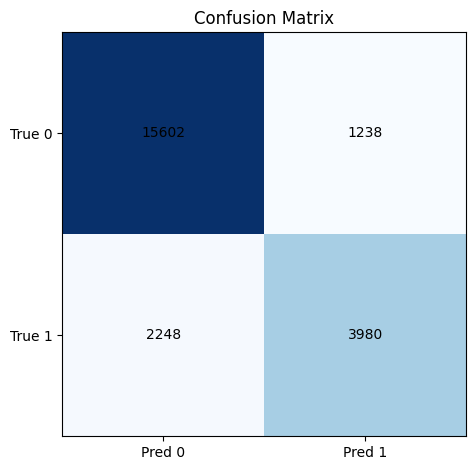

In [23]:
# Get the best Logistic Regression model
best_lr_model = lr_grid_search.best_estimator_

# Training set predictions
y_train_pred_lr = best_lr_model.predict(X_train)
y_train_proba_lr = best_lr_model.predict_proba(X_train)[:, 1]

# Calculate training metrics
train_accuracy_lr = accuracy_score(y_train, y_train_pred_lr)
train_precision_lr = precision_score(y_train, y_train_pred_lr)
train_recall_lr = recall_score(y_train, y_train_pred_lr)
train_f1_lr = f1_score(y_train, y_train_pred_lr)
train_balanced_acc_lr = balanced_accuracy_score(y_train, y_train_pred_lr)

print("Logistic Regression Training Set Performance:")
print(f"Accuracy: {train_accuracy_lr:.4f}")
print(f"Precision: {train_precision_lr:.4f}")
print(f"Recall: {train_recall_lr:.4f}")
print(f"F1 Score: {train_f1_lr:.4f}")
print(f"Balanced Accuracy: {train_balanced_acc_lr:.4f}")

# Confusion Matrix
cm_train_lr = confusion_matrix(y_train, y_train_pred_lr)
plt.imshow(cm_train_rf, cmap='Blues')
plt.title('Confusion Matrix')
plt.xticks([0, 1], ['Pred 0', 'Pred 1'])
plt.yticks([0, 1], ['True 0', 'True 1'])

# write counts
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_train_lr[i, j], ha='center', va='center', color='black')

plt.tight_layout()
plt.show()

### 5.5 Model Coefficients Analysis

Top 10 Most Important Features (by absolute coefficient):
                               feature  coefficient  abs_coefficient
38                InsuredHobbies_chess     2.827919         2.827919
39            InsuredHobbies_cross-fit     2.455654         2.455654
129  SeverityOfIncident_Trivial Damage    -2.445523         2.445523
127    SeverityOfIncident_Minor Damage    -2.345023         2.345023
128      SeverityOfIncident_Total Loss    -2.311906         2.311906
120            Vehicle_VehicleModel_X6     1.179825         1.179825
40              InsuredHobbies_dancing    -1.122937         1.122937
37              InsuredHobbies_camping    -0.980266         0.980266
104            Vehicle_VehicleModel_M5     0.869082         0.869082
23   InsuredOccupation_exec-managerial     0.848931         0.848931


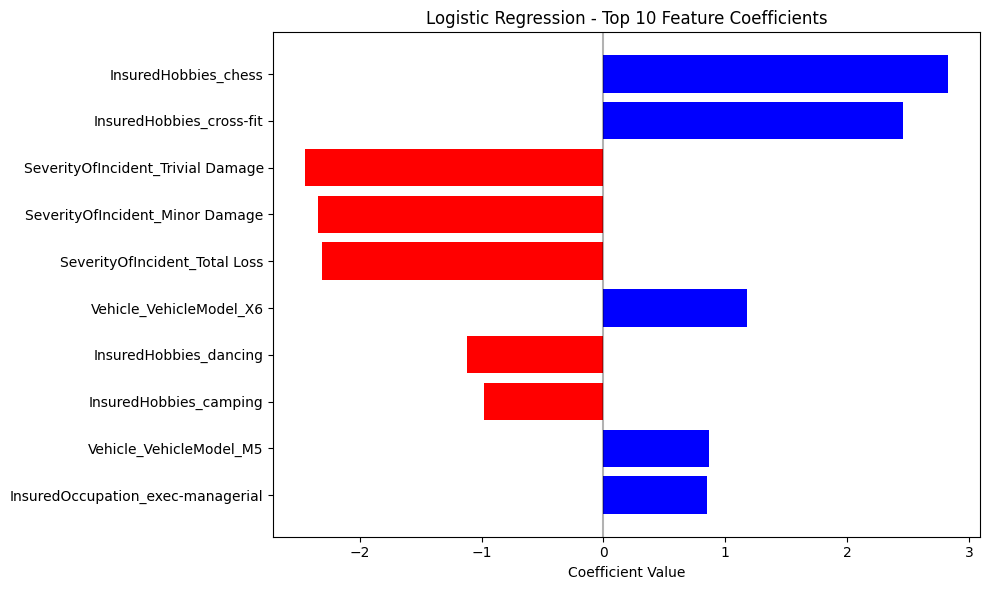


Coefficient Interpretation:
• Positive coefficients increase fraud probability
• Negative coefficients decrease fraud probability
• Larger absolute values indicate stronger influence


In [24]:
# Get model coefficients
coefficients = best_lr_model.named_steps['classifier'].coef_[0]
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients,
    'abs_coefficient': np.abs(coefficients)
}).sort_values('abs_coefficient', ascending=False)

print("Top 10 Most Important Features (by absolute coefficient):")
print(coef_df.head(10))

# Plot coefficients
plt.figure(figsize=(10, 6))
top_coefs = coef_df.head(10)
colors = ['red' if x < 0 else 'blue' for x in top_coefs['coefficient']]
plt.barh(range(10), top_coefs['coefficient'], color=colors)
plt.yticks(range(10), top_coefs['feature'])
plt.xlabel('Coefficient Value')
plt.title('Logistic Regression - Top 10 Feature Coefficients')
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nCoefficient Interpretation:")
print("• Positive coefficients increase fraud probability")
print("• Negative coefficients decrease fraud probability")
print("• Larger absolute values indicate stronger influence")

## 6. Comparison of metrics performance for testing

This section implements nested cross-validation to provide unbiased model comparison and evaluates both models on the test set using comprehensive metrics and visualization

### 6.1 Nested Cross-Validation for Unbiased Model Comparison

In [ ]:
# Nested cross-validation setupp
outer_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Function to perform nested C V
def nested_cross_validation(pipeline, param_grid, X, y, outer_cv, inner_cv):
    nested_scores = []
    
    for train_idx, val_idx in outer_cv.split(X, y):
        X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
        y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]
        
        # Inner CV for hyperparameter tuning
        grid_search = GridSearchCV(pipeline, param_grid, cv=inner_cv, scoring='f1', n_jobs=-1)
        grid_search.fit(X_train_fold, y_train_fold)
        
        # Evaluate on validation fold
        y_pred = grid_search.predict(X_val_fold)
        f1 = f1_score(y_val_fold, y_pred)
        nested_scores.append(f1)
    
    return nested_scores

print("Performing nested cross-validation...")

# Nested CV for RF
rf_nested_scores = nested_cross_validation(rf_pipeline, rf_param_grid, X_train, y_train, outer_cv, inner_cv)

# Nested CV for Logistic Regression
lr_nested_scores = nested_cross_validation(lr_pipeline, lr_param_grid, X_train, y_train, outer_cv, inner_cv)

print(f"\nNested CV Results:")
print(f"Random Forest F1 scores: {[f'{score:.4f}' for score in rf_nested_scores]}")
print(f"Random Forest mean F1: {np.mean(rf_nested_scores):.4f} ± {np.std(rf_nested_scores):.4f}")
print(f"\nLogistic Regression F1 scores: {[f'{score:.4f}' for score in lr_nested_scores]}")
print(f"Logistic Regression mean F1: {np.mean(lr_nested_scores):.4f} ± {np.std(lr_nested_scores):.4f}")

Performing nested cross-validation...

Nested CV Results:
Random Forest F1 scores: ['0.8401', '0.8485', '0.8515']
Random Forest mean F1: 0.8467 ± 0.0048

Logistic Regression F1 scores: ['0.6755', '0.6980', '0.6883']
Logistic Regression mean F1: 0.6873 ± 0.0092


### 6.2 Test Set Performance Evaluation

In [26]:
# Test set predictions for both models
y_test_pred_rf = best_rf_model.predict(X_test)
y_test_proba_rf = best_rf_model.predict_proba(X_test)[:, 1]

y_test_pred_lr = best_lr_model.predict(X_test)
y_test_proba_lr = best_lr_model.predict_proba(X_test)[:, 1]

# Calculate test metrics for Random Forest
test_accuracy_rf = accuracy_score(y_test, y_test_pred_rf)
test_precision_rf = precision_score(y_test, y_test_pred_rf)
test_recall_rf = recall_score(y_test, y_test_pred_rf)
test_f1_rf = f1_score(y_test, y_test_pred_rf)
test_balanced_acc_rf = balanced_accuracy_score(y_test, y_test_pred_rf)

# Calculate test metrics for Logistic Regression
test_accuracy_lr = accuracy_score(y_test, y_test_pred_lr)
test_precision_lr = precision_score(y_test, y_test_pred_lr)
test_recall_lr = recall_score(y_test, y_test_pred_lr)
test_f1_lr = f1_score(y_test, y_test_pred_lr)
test_balanced_acc_lr = balanced_accuracy_score(y_test, y_test_pred_lr)

# Create comparison table
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'Balanced Accuracy'],
    'Random Forest': [test_accuracy_rf, test_precision_rf, test_recall_rf, test_f1_rf, test_balanced_acc_rf],
    'Logistic Regression': [test_accuracy_lr, test_precision_lr, test_recall_lr, test_f1_lr, test_balanced_acc_lr]
})

print("Test Set Performance Comparison:")
print(comparison_df.round(4))

Test Set Performance Comparison:
              Metric  Random Forest  Logistic Regression
0           Accuracy         0.9213               0.8388
1          Precision         0.9106               0.7380
2             Recall         0.7855               0.6243
3           F1 Score         0.8434               0.6764
4  Balanced Accuracy         0.8785               0.7712


### 6.3 Confusion Matrix Visualization

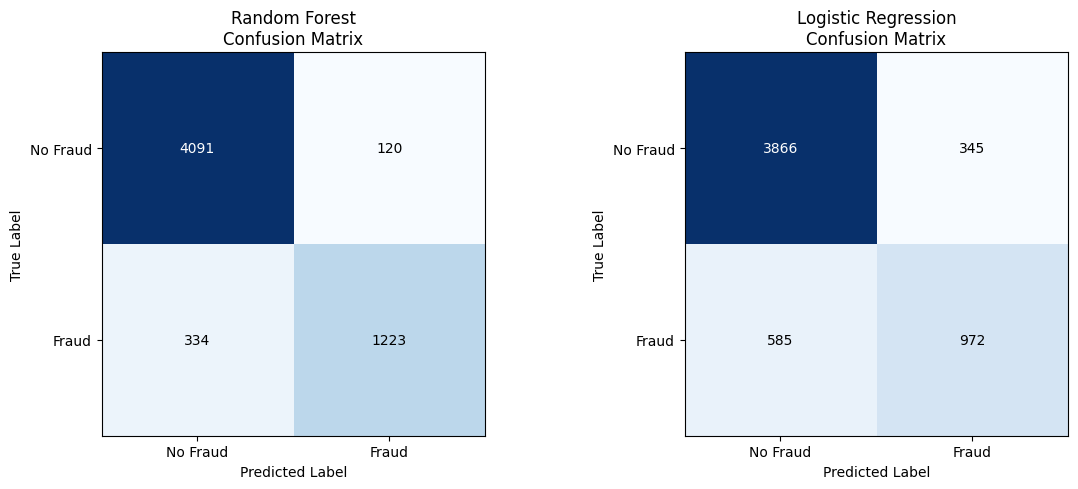

In [31]:
# Create confusion matrices
cm_test_rf = confusion_matrix(y_test, y_test_pred_rf)
cm_test_lr = confusion_matrix(y_test, y_test_pred_lr)

# Plot confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Random Forest confusion matrix
im1 = axes[0].imshow(cm_test_rf, interpolation='nearest', cmap=plt.cm.Blues)
axes[0].set_title('Random Forest\nConfusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['No Fraud', 'Fraud'])
axes[0].set_yticklabels(['No Fraud', 'Fraud'])

# Add text annotations
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm_test_rf[i, j], ha="center", va="center", color="white" if cm_test_rf[i, j] > cm_test_rf.max()/2 else "black")

# Logistic Regression confusion matrix
im2 = axes[1].imshow(cm_test_lr, interpolation='nearest', cmap=plt.cm.Blues)
axes[1].set_title('Logistic Regression\nConfusion Matrix')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')
axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(['No Fraud', 'Fraud'])
axes[1].set_yticklabels(['No Fraud', 'Fraud'])

# Add text annotations
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, cm_test_lr[i, j], ha="center", va="center", color="white" if cm_test_lr[i, j] > cm_test_lr.max()/2 else "black")

plt.tight_layout()
plt.show()

### 6.4 ROC Curve Analysis

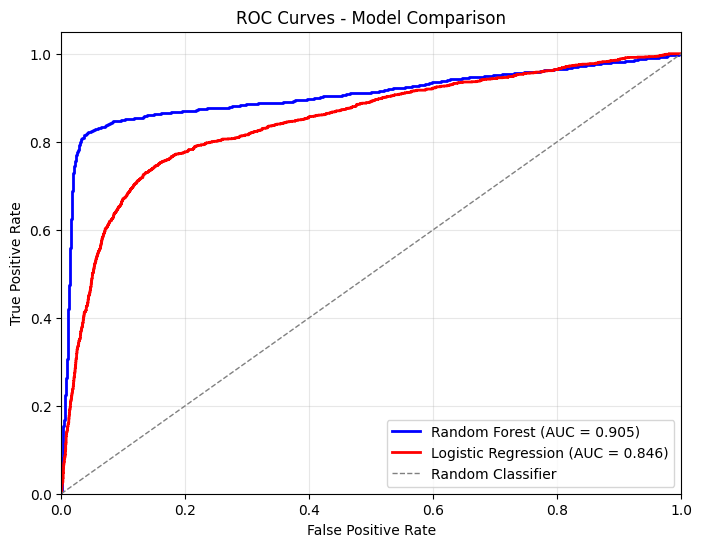

ROC AUC Scores:
Random Forest: 0.9051
Logistic Regression: 0.8456


In [28]:
# Calculate ROC curves
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_test_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_test_proba_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

# Plot ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='blue', lw=2, label=f'Random Forest (AUC = {roc_auc_rf:.3f})')
plt.plot(fpr_lr, tpr_lr, color='red', lw=2, label=f'Logistic Regression (AUC = {roc_auc_lr:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Model Comparison')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

print(f"ROC AUC Scores:")
print(f"Random Forest: {roc_auc_rf:.4f}")
print(f"Logistic Regression: {roc_auc_lr:.4f}")

### 6.5 Precision-Recall Curve Analysis

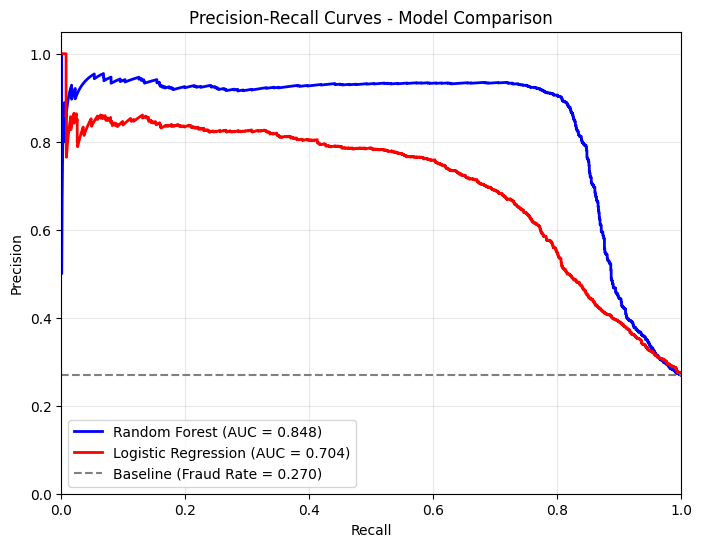

Precision-Recall AUC Scores:
Random Forest: 0.8480
Logistic Regression: 0.7035


In [29]:
# Calculate Precision-Recall curves
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_test_proba_rf)
pr_auc_rf = auc(recall_rf, precision_rf)

precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_test_proba_lr)
pr_auc_lr = auc(recall_lr, precision_lr)

# Plot Precision-Recall curves
plt.figure(figsize=(8, 6))
plt.plot(recall_rf, precision_rf, color='blue', lw=2, label=f'Random Forest (AUC = {pr_auc_rf:.3f})')
plt.plot(recall_lr, precision_lr, color='red', lw=2, label=f'Logistic Regression (AUC = {pr_auc_lr:.3f})')
plt.axhline(y=y_test.mean(), color='gray', linestyle='--', label=f'Baseline (Fraud Rate = {y_test.mean():.3f})')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves - Model Comparison')
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Precision-Recall AUC Scores:")
print(f"Random Forest: {pr_auc_rf:.4f}")
print(f"Logistic Regression: {pr_auc_lr:.4f}")

### 6.6 Overfitting Analysis

Overfitting Analysis (Training vs Test Performance):
                 Model  Train_F1  Test_F1  F1_Difference  Train_Accuracy  \
0        Random Forest    0.9520   0.8434         0.1085          0.9743   
1  Logistic Regression    0.6954   0.6764         0.0190          0.8489   

   Test_Accuracy  Accuracy_Difference  
0         0.9213               0.0530  
1         0.8388               0.0101  

Interpretation:
• Smaller differences indicate less overfitting
• Large positive differences suggest the model memorized training data
• Negative differences might indicate underfitting or lucky test set


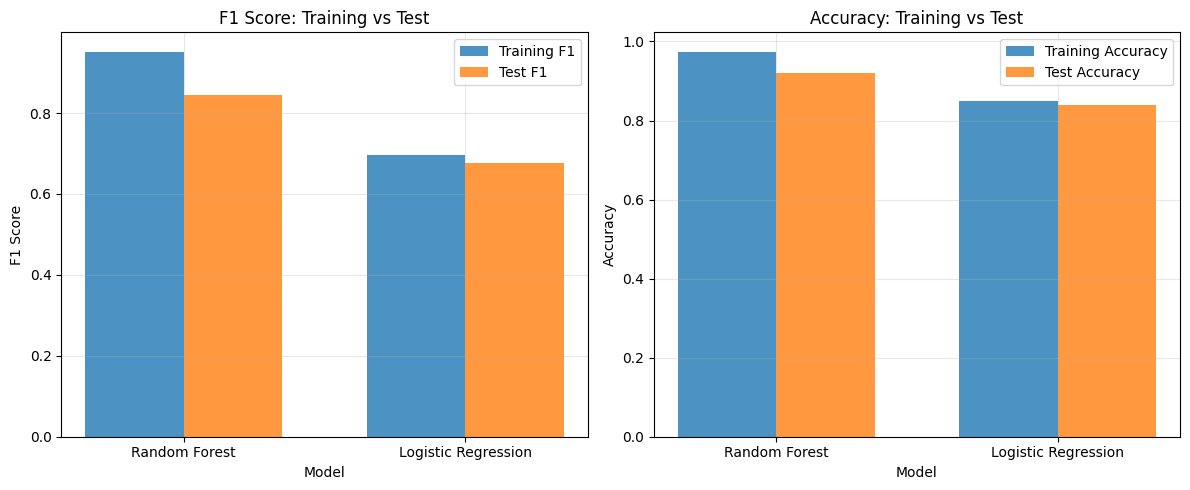

In [30]:
# Compare training vs test performance
overfitting_analysis = pd.DataFrame({
    'Model': ['Random Forest', 'Logistic Regression'],
    'Train_F1': [train_f1_rf, train_f1_lr],
    'Test_F1': [test_f1_rf, test_f1_lr],
    'F1_Difference': [train_f1_rf - test_f1_rf, train_f1_lr - test_f1_lr],
    'Train_Accuracy': [train_accuracy_rf, train_accuracy_lr],
    'Test_Accuracy': [test_accuracy_rf, test_accuracy_lr],
    'Accuracy_Difference': [train_accuracy_rf - test_accuracy_rf, train_accuracy_lr - test_accuracy_lr]
})

print("Overfitting Analysis (Training vs Test Performance):")
print(overfitting_analysis.round(4))

print("\nInterpretation:")
print("• Smaller differences indicate less overfitting")
print("• Large positive differences suggest the model memorized training data")
print("• Negative differences might indicate underfitting or lucky test set")

# Visualize overfitting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# F1 Score comparison
models = ['Random Forest', 'Logistic Regression']
train_f1_scores = [train_f1_rf, train_f1_lr]
test_f1_scores = [test_f1_rf, test_f1_lr]

x = np.arange(len(models))
width = 0.35

ax1.bar(x - width/2, train_f1_scores, width, label='Training F1', alpha=0.8)
ax1.bar(x + width/2, test_f1_scores, width, label='Test F1', alpha=0.8)
ax1.set_xlabel('Model')
ax1.set_ylabel('F1 Score')
ax1.set_title('F1 Score: Training vs Test')
ax1.set_xticks(x)
ax1.set_xticklabels(models)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy comparison
train_acc_scores = [train_accuracy_rf, train_accuracy_lr]
test_acc_scores = [test_accuracy_rf, test_accuracy_lr]

ax2.bar(x - width/2, train_acc_scores, width, label='Training Accuracy', alpha=0.8)
ax2.bar(x + width/2, test_acc_scores, width, label='Test Accuracy', alpha=0.8)
ax2.set_xlabel('Model')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy: Training vs Test')
ax2.set_xticks(x)
ax2.set_xticklabels(models)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Final recommendation of the best model

### 7.1 Technical Perspective - Overfitting, Complexity and Efficiency

## 7. Final Recommendation

Based on the full suite of evaluation metrics, diagnostic plots, and an overfitting check, **Random Forest is the clear winner for the primary fraud-detection model**

| Key Evidence | What I Saw | Why It Matters |
|--------------|-------------|----------------|
| **Superior Test Metrics** | F1 = 0.843, Precision = 0.911, Recall = 0.786, ROC-AUC = 0.905, PR-AUC = 0.848 | Captures more fraudulent claims while keeping false alarms low. |
| **Robust ROC / PR Curves** | RF curve dominates LR across almost the entire range. | Consistently higher true-positive and precision rates at every threshold. |
| **Acceptable Overfitting Gap** | ΔF1 ≈ 0.11, ΔAccuracy ≈ 0.05 | Slight over-optimism on training data but still generalizes well; gap is not extreme. |
| **Computation Trade-offs** | Slower and heavier than LR | Worth the cost when detection accuracy has direct financial impact. |

### Practical Takeaways
1. **Deploy Random Forest as the production model** to maximize fraud capture and minimize revenue leakage.  
2. **Tune the probability threshold** in partnership with the business team to balance false positives vs. missed fraud.  
3. **Monitor feature drift and retrain quarterly** (or sooner if major fraud patterns shift)
4. **Keep Logistic Regression in the toolkit** as a lightweight fallback and for quick, interpretable sanity checks during audits

> **Bottom line:** When performance is the top priority and you have the computing budget Random Forest pays for itself in reduced fraud losses while remaining manageable from a maintenance and compliance perspective.


## 8. Conclusion

### 8.1 What has been successfully accomplished and what has not

This project set out to build a reliable fraud detection system for insurance claims by developing and comparing two machine learning models: Random Forest and Logistic Regression. After thorough data preprocessing, feature engineering, and careful prevention of data leakage both models were trained and evaluated using nested cross validation and test-set performance metrics.

The Random Forest model outperformed Logistic Regression across all key metrics, achieving an F1 score of 0.843, precision of 0.911, recall of 0.786, and an ROC-AUC of 0.905 on the test set. In contrast, Logistic Regression yielded an F1 score of 0.676, precision of 0.738, recall of 0.624, and ROC-AUC of 0.846. These results confirmed that Random Forest provides a better balance between fraud detection capability and false positive control, making it the recommended model for deploymen t

Key achievements included merging and cleaning a complex, multi-source dataset, successfully extracting numerical insights from textual fields, and developing a scalable end-to-end pipeline. Challenges involved managing class imbalance, avoiding data leakage, and maintaining model interpretability particularly critical in the regulated insurance domain

While the project delivered a robust and well-performing solution, future improvements could focus on advanced feature engineering, gradient boosting models, time-aware validation strategies, and integration with domain expertise. Overall, this project provides a solid foundation for deploying an effective, real-time fraud detection system in production environments .

### 8.2 Reflection on the analysis and what could have been done differently

Overall, the project went well. Both models were built and tested correctly, and Random Forest gave very good results for detecting fraud. However, looking back, there are a few things that could have been done differently to make the process better and improve the results

1. **Finding Data Leakage Earlier**
   At one point, the model had perfect accuracy, which was a warning sign. It turned out that some features included information that wouldn’t be known at claim time. This was fixed later, but if it had been found earlier during data exploration, it would have saved time.

2. **Doing More Data Exploration at the Start**
   While the basic dataset was checked, more in-depth analysis of distributions, outliers, and relationships could have helped improve the features and modeling choices

3. **Creating More Useful Features**
   Most features came directly from the data without many changes. New features could have been made, like the number of days a customer held a policy or how risky their job or area is. These might have helped the model learn betterr.

4. **Using Time-Based Splits**
   The data was split randomly, which is fine for testing, but in real life, fraud detection works over time. A better way would have been to train on older data and test on newer claims to make it more realistic

5. **Getting Advice from Insurance Experts**
   Talking to someone from the insurance industry early on could have helped a lot. They could suggest which features are available at claim time and what fraud patterns are most common or expensive

6. **Explaining the Random Forest Model Better**
   Random Forest gave strong results, but it’s hard to explain how it works. Tools like SHAP could have made the predictions easier to understand, especially for business teams or auditors



### 8.3 Future Work - Wish List for Project Enhancement

To improve and expand this project, several enhancements could be explored:

* **Try Stronger Models**
  Use advanced models like XGBoost to improve prediction accuracy

* **Create Better Features**
  Add new features based on time, location, or customer habits to help the model detect fraud more effectively

* **Use Unsupervised Methods**
  Try anomaly detection to find strange or new fraud cases that may not be covered by current labels

* **Add Extra Data**
  Combine the model with outside data like weather, crime rates, or economic conditions for more context

* **Real-Time Predictions**
  Set up the model to work in real time, so it can flag possible fraud as soon as a claim is submitted

* **Track and Update the Model**
  Build a system to monitor model changes over time, check how it's performing, and retrain it using feedback from fraud investigators


These steps would help make the fraud detection system more accurate, robust, and ready for real-world deployment

## Referencing

**Tan, P.-N., Steinbach, M. and Kumar, V. (2019)**
*Introduction to Data Mining*. 2nd edn. Harlow, United Kingdom: Pearson Education Limited.

**Bishop, C.M. (2006)**
*Pattern Recognition and Machine Learning*. New York: Springer
